In [1]:
# !pip install keras-tuner

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import keras
from keras import layers
from keras import ops
from tensorflow.keras.models import Sequential
import keras_tuner as kt

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler


import matplotlib.pyplot as plt
import random
import time
import seaborn as sns

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

#Supress Warnings
import warnings
warnings.filterwarnings('ignore')

import gc


I0000 00:00:1776713855.773986    9328 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776713858.428842    9328 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# %cd /content/drive/MyDrive/590-ners/590 ML Project - Measurements/BACKUPS/Project/MLDPPCC

In [5]:
# load
d = np.load("processed_waveforms.npz")
 # ["X_euclidean"] or ["X_voltage"]
X = d["X_voltage"].astype(np.float32)
# 0=photon, 1=neutron
y = d["y"].astype(np.int32)

# 60/20/20 train/val/test split
# First split off 20% test
X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# Then split remaining 80% into 60% train + 20% val (0.25 of 80% = 20% of total)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_trainval, Y_trainval, test_size=0.25, random_state=42, stratify=Y_trainval)

# Per-waveform min-max normalization to [0, 1].
# Each waveform is rescaled independently using its own min and max, so
# the lowest sample in every waveform becomes 0 and the highest becomes 1.
# This strips per-pulse amplitude information, forcing the model to learn
# from shape alone.
def per_waveform_minmax(X):
    X = X.astype(np.float32)
    mn = X.min(axis=1, keepdims=True)
    mx = X.max(axis=1, keepdims=True)
    rng = np.maximum(mx - mn, 1e-8)
    return (X - mn) / rng

X_train = per_waveform_minmax(X_train)
X_val   = per_waveform_minmax(X_val)
X_test  = per_waveform_minmax(X_test)

latent_dim = 16
input_length = X_train.shape[1]

#  Encoder 
inputs = tf.keras.Input(shape=(input_length, 1))
x = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(2, padding='same')(x)
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)
shape = x.shape[1:]

# Feature vector
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, name="latent")(x) #Flatten into latent dimension

#  Decoder (input is feature vector) 
x = layers.Dense(shape[0] * shape[1], activation='relu')(latent)
x = layers.Reshape(shape)(x)
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)

#Reconstructed Signal
reconstruction = layers.Conv1D(1, 3, padding='same', name="reconstruction")(x)

#  Classifier 
clf = layers.Dense(32, activation='relu')(latent)
#clf = layers.Dense(16, activation='relu')(clf)
classification = layers.Dense(1, activation='sigmoid', name="classification")(clf)

# Full Model
model = Model(inputs, [reconstruction, classification])

X_test_n = X_test
X_train_n = X_train

I0000 00:00:1776713863.003039    9328 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12672 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [6]:
model.compile(
    optimizer='adam',
    loss={
        'reconstruction': 'mse',
        'classification': 'binary_crossentropy'},
    loss_weights={
        'reconstruction': 30.0,
        'classification': 1.0},
    metrics={
        'classification': ['accuracy']})


In [7]:
early_stop_initial = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode='min'
)

initial_history = model.fit(
    X_train,
    {
        "reconstruction": X_train,
        "classification": Y_train},
    validation_data=(
        X_val,
        {
            "reconstruction": X_val,
            "classification": Y_val}
    ),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_initial]
)

Epoch 1/100


I0000 00:00:1776713865.183833    9558 service.cc:153] XLA service 0x7f5b2003b090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776713865.183849    9558 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.19.0)
I0000 00:00:1776713865.252562    9558 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776713865.539951    9558 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1776713865.558282    9558 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4668__.46
I0000 00:00:1776713866.298925    9713 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads

E0000 00:00:1776713866.590142    9698 cuda_timer.cc:87] Delay kernel timed ou

  61/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - classification_accuracy: 0.6557 - classification_loss: 0.6334 - loss: 1.1780 - reconstruction_loss: 0.0182

I0000 00:00:1776713868.322884    9558 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1214/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - classification_accuracy: 0.9397 - classification_loss: 0.1395 - loss: 0.2204 - reconstruction_loss: 0.0027

I0000 00:00:1776713871.484659    9552 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4668__.46
E0000 00:00:1776713872.304491   10131 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1219/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - classification_accuracy: 0.9399 - classification_loss: 0.1391 - loss: 0.2198 - reconstruction_loss: 0.0027

I0000 00:00:1776713873.947186    9552 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12626__.14
I0000 00:00:1776713874.767797    9552 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12626__.14


1219/1219 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - classification_accuracy: 0.9786 - classification_loss: 0.0538 - loss: 0.0838 - reconstruction_loss: 9.9994e-04 - val_classification_accuracy: 0.9929 - val_classification_loss: 0.0177 - val_loss: 0.0330 - val_reconstruction_loss: 5.1112e-04
Epoch 2/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - classification_accuracy: 0.9921 - classification_loss: 0.0192 - loss: 0.0331 - reconstruction_loss: 4.6098e-04 - val_classification_accuracy: 0.9923 - val_classification_loss: 0.0183 - val_loss: 0.0309 - val_reconstruction_loss: 4.2284e-04
Epoch 3/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - classification_accuracy: 0.9929 - classification_loss: 0.0170 - loss: 0.0296 - reconstruction_loss: 4.2041e-04 - val_classification_accuracy: 0.9912 - val_classification_loss: 0.0193 - val_loss: 0.0308 - val_reconstruction_loss: 3.8474e-04
Epoch 4/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - classification_accuracy: 0.9931 - classification_loss: 0.0168 -

I0000 00:00:1776713936.616610    9552 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_192406__.7


3247/3251 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step

I0000 00:00:1776713938.384008    9553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_202463__.7
E0000 00:00:1776713938.629557   13620 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3251/3251 ━━━━━━━━━━━━━━━━━━━━ 2s 573us/step


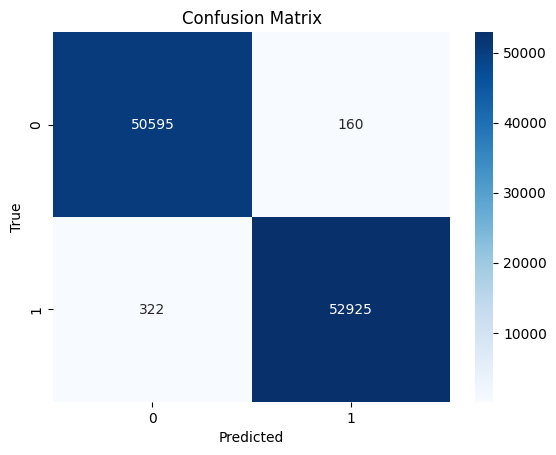

In [8]:
# Get predictions
y_pred = model.predict(X_test_n)[1]

# Convert probabilities from sigmoid to binary
y_pred_bin = (y_pred > 0.5).astype(int)

# Plot confusion matrix for each label
cm = confusion_matrix(Y_test, y_pred_bin)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

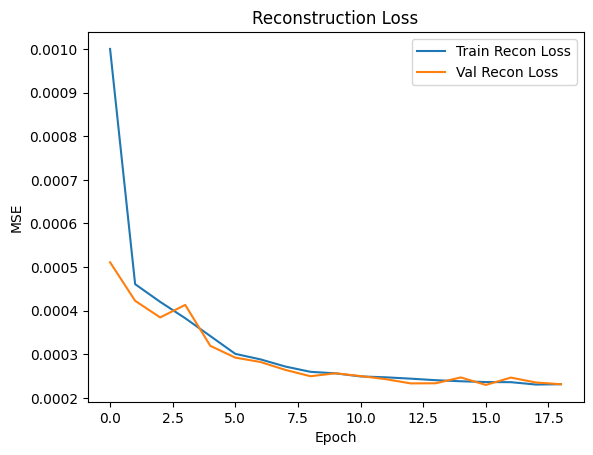

In [9]:
plt.figure()
plt.plot(initial_history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(initial_history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

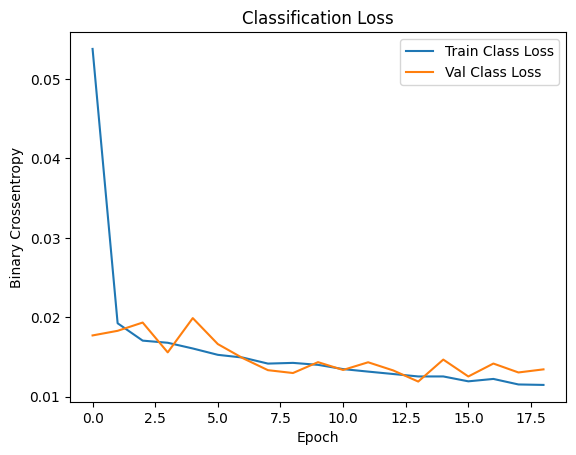

In [10]:
plt.figure()
plt.plot(initial_history.history['classification_loss'], label='Train Class Loss')
plt.plot(initial_history.history['val_classification_loss'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

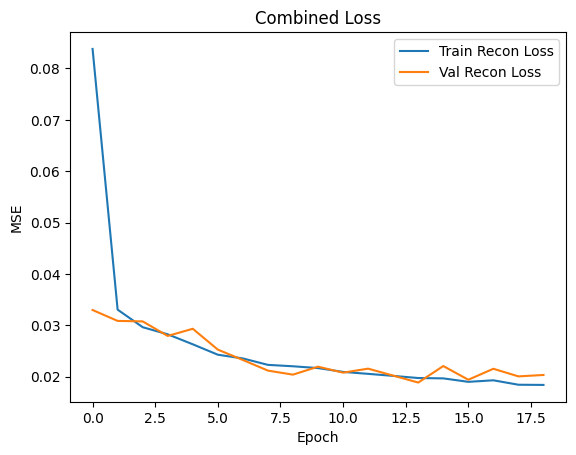

In [11]:
plt.figure()
plt.plot(initial_history.history['loss'], label='Train Recon Loss')
plt.plot(initial_history.history['val_loss'], label='Val Recon Loss')
plt.title('Combined Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [12]:
#Hyper parameter tuning 

In [13]:
def resolve_filters(conv_filters, num_layers):
    """Option A: truncate if fewer layers, extend by doubling if more."""
    f = list(conv_filters)
    if num_layers <= len(f):
        return tuple(f[:num_layers])
    while len(f) < num_layers:
        f.append(f[-1] * 2)
    return tuple(f)


def build_model(latent_dim=8,
                conv_filters=(32, 64, 128),
                dense_units=32,
                lr=1e-3,
                num_layers=3):

    filters = resolve_filters(conv_filters, num_layers)

    inputs = tf.keras.Input(shape=(input_length, 1))

    # Encoder: num_layers Conv1D + MaxPool blocks
    x = inputs
    for f in filters:
        x = layers.Conv1D(f, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2, padding='same')(x)

    shape = x.shape[1:]

    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name="latent")(x)

    # Decoder: mirror encoder (UpSampling + Conv1D), filters reversed
    x = layers.Dense(shape[0] * shape[1], activation='relu')(latent)
    x = layers.Reshape(shape)(x)
    for f in reversed(filters):
        x = layers.UpSampling1D(2)(x)
        x = layers.Conv1D(f, 3, activation='relu', padding='same')(x)

    # Crop decoder output to match input length (handles odd-length pooling asymmetry)
    x = layers.Lambda(lambda t: t[:, :input_length, :], output_shape=(input_length, filters[0]))(x)

    reconstruction = layers.Conv1D(1, 3, padding='same', name="reconstruction")(x)

    # Classifier head
    clf = layers.Dense(dense_units, activation='relu')(latent)
    classification = layers.Dense(1, activation='sigmoid', name="classification")(clf)

    model = Model(inputs, [reconstruction, classification])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss={
            "reconstruction": "mse",
            "classification": "binary_crossentropy"
        },
        loss_weights={"reconstruction": 30.0, "classification": 1.0},
        metrics={"classification": "accuracy"}
    )

    return model

In [14]:
import itertools

param_grid = {
    # Keep fixed at 8: 104 -> 8 follows rule of thumb
    "latent_dim":   [8],
    "conv_filters": [(16, 32, 64), (32, 64, 128), (64, 128, 256)],
    "dense_units":  [16, 32, 64, 128],
    "lr":           [1e-2, 1e-3, 1e-4],
    "num_layers":   [2, 3, 4],
}

def param_combinations():
    keys = list(param_grid.keys())
    for values in itertools.product(*param_grid.values()):
        yield dict(zip(keys, values))

all_params = list(param_combinations())
print(f"Total combinations: {len(all_params)}")

Total combinations: 108


In [15]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode = 'min'
)

In [16]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_classification_accuracy",
    save_best_only=True,
    mode='max'
)

In [17]:
import csv, os

best_score = -np.inf
best_model = None
best_params = None

results_path = "A1_SinglesApril20_hyperparam_results.csv"
fieldnames = ["trial", "latent_dim", "conv_filters", "dense_units", "lr", "num_layers",
              "best_val_acc", "best_val_recon_loss", "best_val_loss", "epochs_run"]

# Resume logic: if CSV exists, read completed configs and recover best_score
completed_keys = set()
if os.path.exists(results_path):
    with open(results_path, newline="") as f:
        for row in csv.DictReader(f):
            key = (row["conv_filters"], int(row["dense_units"]),
                   float(row["lr"]), int(row["num_layers"]))
            completed_keys.add(key)
            acc = float(row["best_val_acc"])
            if acc > best_score:
                best_score = acc
                best_params = {
                    "latent_dim":   int(row["latent_dim"]),
                    "conv_filters": eval(row["conv_filters"]),
                    "dense_units":  int(row["dense_units"]),
                    "lr":           float(row["lr"]),
                    "num_layers":   int(row["num_layers"]),
                }
    print(f"Resuming: {len(completed_keys)} trials already done. Best so far: {best_score}")
else:
    with open(results_path, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=fieldnames).writeheader()
    print("Starting fresh")


Resuming: 52 trials already done. Best so far: 0.9954327940940857


In [18]:
for i, params in enumerate(all_params):
    key = (str(params["conv_filters"]), params["dense_units"],
           params["lr"], params["num_layers"])
    if key in completed_keys:
        print(f"\nTrial {i+1}/{len(all_params)}: SKIP (already done) {params}")
        continue

    tf.keras.backend.clear_session()
    gc.collect()
    print(f"\nTrial {i+1}/{len(all_params)}")

    model = build_model(**params)

    early_stop_trial = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode='min'
    )
    checkpoint_trial = tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_classification_accuracy",
        save_best_only=True,
        mode='max'
    )

    history = model.fit(
        X_train,
        {"reconstruction": X_train, "classification": Y_train},
        validation_data=(X_val, {"reconstruction": X_val, "classification": Y_val}),
        epochs=100,
        batch_size=256,
        callbacks=[early_stop_trial, checkpoint_trial],
        verbose=2
    )

    h = history.history
    val_acc = max(h["val_classification_accuracy"])

    row = {
        "trial": i + 1,
        "latent_dim": params["latent_dim"],
        "conv_filters": str(params["conv_filters"]),
        "dense_units": params["dense_units"],
        "lr": params["lr"],
        "num_layers": params["num_layers"],
        "best_val_acc": val_acc,
        "best_val_recon_loss": min(h["val_reconstruction_loss"]),
        "best_val_loss": min(h["val_loss"]),
        "epochs_run": len(h["val_loss"]),
    }
    with open(results_path, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=fieldnames).writerow(row)

    print("Params:", params)
    print("Best val acc:", val_acc)

    if val_acc > best_score:
        best_score = val_acc
        best_model = model
        best_params = params



Trial 1/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.01, 'num_layers': 2}

Trial 2/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.01, 'num_layers': 3}

Trial 3/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.01, 'num_layers': 4}

Trial 4/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.001, 'num_layers': 2}

Trial 5/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.001, 'num_layers': 3}

Trial 6/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.001, 'num_layers': 4}

Trial 7/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.0001, 'num_layers': 2}

Trial 8/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'de

I0000 00:00:1776713941.465040    9558 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_239736__.46
E0000 00:00:1776713942.074788   13825 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1776713946.367223    9548 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_239736__.46
I0000 00:00:1776713946.627176   14043 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 20 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776713946.673566   14050 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_12', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776713946.707376   14051 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'g

1219/1219 - 10s - 8ms/step - classification_accuracy: 0.9060 - classification_loss: 0.2075 - loss: 0.2828 - reconstruction_loss: 0.0025 - val_classification_accuracy: 0.9814 - val_classification_loss: 0.0536 - val_loss: 0.0730 - val_reconstruction_loss: 6.4284e-04
Epoch 2/100
1219/1219 - 3s - 3ms/step - classification_accuracy: 0.9861 - classification_loss: 0.0377 - loss: 0.0558 - reconstruction_loss: 6.0332e-04 - val_classification_accuracy: 0.9892 - val_classification_loss: 0.0277 - val_loss: 0.0448 - val_reconstruction_loss: 5.6860e-04
Epoch 3/100
1219/1219 - 3s - 3ms/step - classification_accuracy: 0.9907 - classification_loss: 0.0239 - loss: 0.0404 - reconstruction_loss: 5.4693e-04 - val_classification_accuracy: 0.9910 - val_classification_loss: 0.0221 - val_loss: 0.0380 - val_reconstruction_loss: 5.2882e-04
Epoch 4/100
1219/1219 - 3s - 3ms/step - classification_accuracy: 0.9918 - classification_loss: 0.0202 - loss: 0.0354 - reconstruction_loss: 5.0794e-04 - val_classification_acc

I0000 00:00:1776714106.355613    9548 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_710831__.57
E0000 00:00:1776714107.418233   21913 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1776714107.635476   21896 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_select_transpose_fusion', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1776714107.639464   21907 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_select_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776714112.814122    9558 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_710831__.57
I0000 00:00:1776714112.947075   22346 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory 

1219/1219 - 13s - 10ms/step - classification_accuracy: 0.9209 - classification_loss: 0.1708 - loss: 0.2340 - reconstruction_loss: 0.0021 - val_classification_accuracy: 0.9830 - val_classification_loss: 0.0439 - val_loss: 0.0635 - val_reconstruction_loss: 6.5267e-04
Epoch 2/100
1219/1219 - 4s - 3ms/step - classification_accuracy: 0.9873 - classification_loss: 0.0324 - loss: 0.0508 - reconstruction_loss: 6.1381e-04 - val_classification_accuracy: 0.9881 - val_classification_loss: 0.0298 - val_loss: 0.0482 - val_reconstruction_loss: 6.1376e-04
Epoch 3/100
1219/1219 - 4s - 4ms/step - classification_accuracy: 0.9906 - classification_loss: 0.0231 - loss: 0.0402 - reconstruction_loss: 5.6998e-04 - val_classification_accuracy: 0.9912 - val_classification_loss: 0.0214 - val_loss: 0.0380 - val_reconstruction_loss: 5.5452e-04
Epoch 4/100
1219/1219 - 4s - 4ms/step - classification_accuracy: 0.9915 - classification_loss: 0.0205 - loss: 0.0368 - reconstruction_loss: 5.4460e-04 - val_classification_ac

...

1219/1219 - 8s - 6ms/step - classification_accuracy: 0.8882 - classification_loss: 0.2287 - loss: 0.2999 - reconstruction_loss: 0.0024 - val_classification_accuracy: 0.9817 - val_classification_loss: 0.0515 - val_loss: 0.0693 - val_reconstruction_loss: 5.9248e-04
Epoch 2/100
1219/1219 - 4s - 3ms/step - classification_accuracy: 0.9869 - classification_loss: 0.0348 - loss: 0.0513 - reconstruction_loss: 5.4954e-04 - val_classification_accuracy: 0.9901 - val_classification_loss: 0.0248 - val_loss: 0.0403 - val_reconstruction_loss: 5.1597e-04
Epoch 3/100
1219/1219 - 4s - 3ms/step - classification_accuracy: 0.9914 - classification_loss: 0.0218 - loss: 0.0368 - reconstruction_loss: 4.9938e-04 - val_classification_accuracy: 0.9919 - val_classification_loss: 0.0200 - val_loss: 0.0343 - val_reconstruction_loss: 4.7973e-04
Epoch 4/100
1219/1219 - 4s - 3ms/step - classification_accuracy: 0.9924 - classification_loss: 0.0188 - loss: 0.0328 - reconstruction_loss: 4.6620e-04 - val_classification_accu

I0000 00:00:1776721113.459979    9548 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16018646__.46
I0000 00:00:1776721119.239113    9548 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16018646__.46
I0000 00:00:1776721120.650104    9553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16026608__.14
I0000 00:00:1776721121.356344    9552 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16026608__.14


1219/1219 - 9s - 8ms/step - classification_accuracy: 0.9138 - classification_loss: 0.1655 - loss: 0.2191 - reconstruction_loss: 0.0018 - val_classification_accuracy: 0.9858 - val_classification_loss: 0.0365 - val_loss: 0.0542 - val_reconstruction_loss: 5.9054e-04
Epoch 2/100
1219/1219 - 5s - 4ms/step - classification_accuracy: 0.9894 - classification_loss: 0.0265 - loss: 0.0433 - reconstruction_loss: 5.5996e-04 - val_classification_accuracy: 0.9914 - val_classification_loss: 0.0212 - val_loss: 0.0373 - val_reconstruction_loss: 5.3635e-04
Epoch 3/100
1219/1219 - 5s - 4ms/step - classification_accuracy: 0.9922 - classification_loss: 0.0196 - loss: 0.0344 - reconstruction_loss: 4.9530e-04 - val_classification_accuracy: 0.9908 - val_classification_loss: 0.0217 - val_loss: 0.0357 - val_reconstruction_loss: 4.7142e-04
Epoch 4/100
1219/1219 - 5s - 4ms/step - classification_accuracy: 0.9927 - classification_loss: 0.0179 - loss: 0.0315 - reconstruction_loss: 4.5271e-04 - val_classification_accu

I0000 00:00:1776721338.388237    9553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16459373__.57
I0000 00:00:1776721339.771878    9553 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_5', 56 bytes spill stores, 56 bytes spill loads

I0000 00:00:1776721345.889017    9553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16459373__.57
I0000 00:00:1776721347.588131    9559 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16467423__.16
I0000 00:00:1776721348.496124    9548 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16467423__.16


1219/1219 - 12s - 10ms/step - classification_accuracy: 0.9384 - classification_loss: 0.1317 - loss: 0.1777 - reconstruction_loss: 0.0015 - val_classification_accuracy: 0.9879 - val_classification_loss: 0.0296 - val_loss: 0.0476 - val_reconstruction_loss: 5.9929e-04
Epoch 2/100
1219/1219 - 7s - 5ms/step - classification_accuracy: 0.9903 - classification_loss: 0.0240 - loss: 0.0412 - reconstruction_loss: 5.7447e-04 - val_classification_accuracy: 0.9917 - val_classification_loss: 0.0204 - val_loss: 0.0364 - val_reconstruction_loss: 5.3453e-04
Epoch 3/100
1219/1219 - 7s - 6ms/step - classification_accuracy: 0.9920 - classification_loss: 0.0195 - loss: 0.0350 - reconstruction_loss: 5.1516e-04 - val_classification_accuracy: 0.9913 - val_classification_loss: 0.0207 - val_loss: 0.0356 - val_reconstruction_loss: 4.9591e-04
Epoch 4/100
1219/1219 - 7s - 6ms/step - classification_accuracy: 0.9925 - classification_loss: 0.0183 - loss: 0.0328 - reconstruction_loss: 4.8215e-04 - val_classification_ac

In [19]:
print("BEST SCORE:", best_score)
print("BEST PARAMS:", best_params)

BEST SCORE: 0.9956539273262024
BEST PARAMS: {'latent_dim': 8, 'conv_filters': (64, 128, 256), 'dense_units': 32, 'lr': 0.001, 'num_layers': 2}


Rebuilt best model from best_params: {'latent_dim': 8, 'conv_filters': (64, 128, 256), 'dense_units': 32, 'lr': 0.001, 'num_layers': 2}
Epoch 1/100


I0000 00:00:1776721581.615933    9556 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16819888__.35


1205/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_accuracy: 0.9403 - classification_loss: 0.1361 - loss: 0.2082 - reconstruction_loss: 0.0024

I0000 00:00:1776721586.031226    9556 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16819888__.35


1219/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - classification_accuracy: 0.9407 - classification_loss: 0.1351 - loss: 0.2067 - reconstruction_loss: 0.0024

...

1219/1219 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - classification_accuracy: 0.9788 - classification_loss: 0.0524 - loss: 0.0789 - reconstruction_loss: 8.8198e-04 - val_classification_accuracy: 0.9924 - val_classification_loss: 0.0187 - val_loss: 0.0323 - val_reconstruction_loss: 4.5663e-04
Epoch 2/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - classification_accuracy: 0.9923 - classification_loss: 0.0189 - loss: 0.0312 - reconstruction_loss: 4.1221e-04 - val_classification_accuracy: 0.9923 - val_classification_loss: 0.0187 - val_loss: 0.0303 - val_reconstruction_loss: 3.8906e-04
Epoch 3/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - classification_accuracy: 0.9928 - classification_loss: 0.0178 - loss: 0.0293 - reconstruction_loss: 3.8226e-04 - val_classification_accuracy: 0.9937 - val_classification_loss: 0.0156 - val_loss: 0.0266 - val_reconstruction_loss: 3.6681e-04
Epoch 4/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - classification_accuracy: 0.9931 - classification_loss: 0.0166 - 

I0000 00:00:1776721670.069406    9553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17046702__.5
I0000 00:00:1776721670.227134  299978 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads



3166/3251 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step

I0000 00:00:1776721671.732019    9556 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17056691__.5


3251/3251 ━━━━━━━━━━━━━━━━━━━━ 2s 504us/step


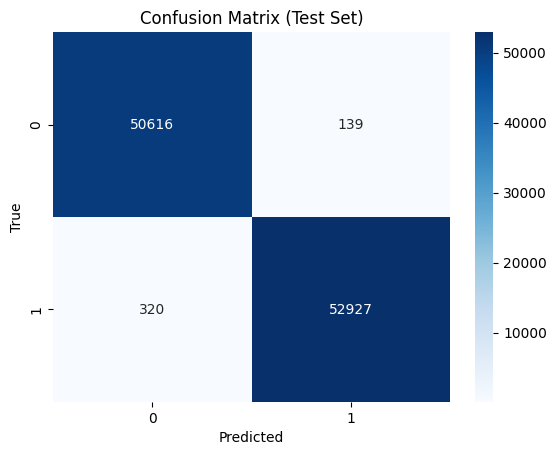

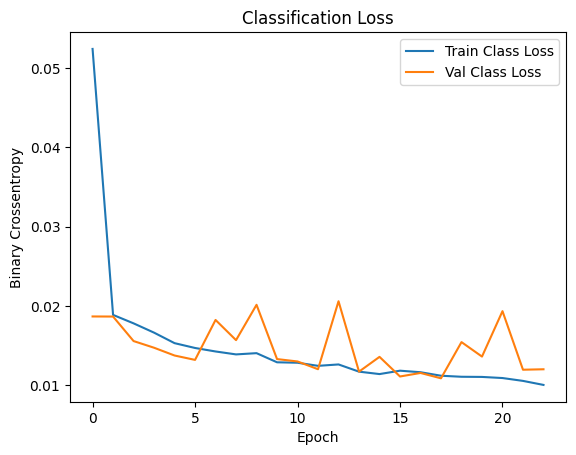

In [20]:
# Rebuild best model from best_params
best_model = build_model(**best_params)
print("Rebuilt best model from best_params:", best_params)

early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode='min'
)

history = best_model.fit(
    X_train,
    {
        "reconstruction": X_train,
        "classification": Y_train},
    validation_data=(
        X_val,
        {
            "reconstruction": X_val,
            "classification": Y_val}
    ),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_final]
)

# Final evaluation on held-out test set (untouched during tuning)
y_pred = best_model.predict(X_test)[1]
y_pred_bin = (y_pred > 0.5).astype(int)

cm = confusion_matrix(Y_test, y_pred_bin)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

plt.figure()
plt.plot(history.history['classification_loss'], label='Train Class Loss')
plt.plot(history.history['val_classification_loss'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()


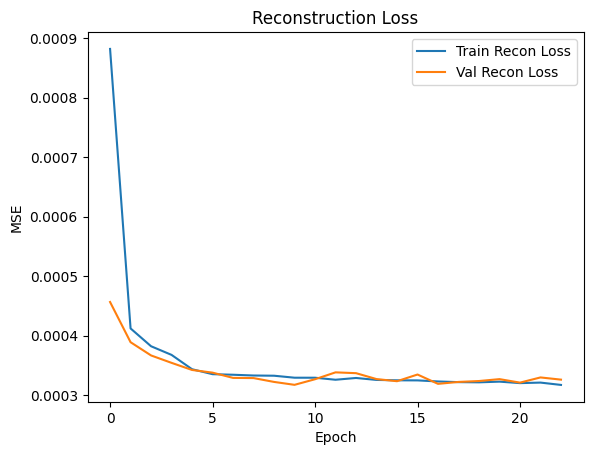

In [21]:
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

Top 1 configuration by best_val_acc:
 trial conv_filters  dense_units    lr  num_layers  best_val_acc
    13 (16, 32, 64)           32 0.001           2       0.99499

=== Training top-1 config (trial 13): {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 32, 'lr': 0.001, 'num_layers': 2} ===
Epoch 1/100


I0000 00:00:1776721675.551281    9553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17093183__.35
I0000 00:00:1776721675.813745  300332 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776721679.734752    9556 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17093183__.35
I0000 00:00:1776721680.063011  300734 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 20 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776721680.229045  300740 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776721680.297634  300736 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in funct

1219/1219 - 9s - 7ms/step - classification_accuracy: 0.9646 - classification_loss: 0.0860 - loss: 0.1202 - reconstruction_loss: 0.0011 - val_classification_accuracy: 0.9869 - val_classification_loss: 0.0330 - val_loss: 0.0480 - val_reconstruction_loss: 4.9898e-04
Epoch 2/100
1219/1219 - 3s - 2ms/step - classification_accuracy: 0.9918 - classification_loss: 0.0200 - loss: 0.0335 - reconstruction_loss: 4.5252e-04 - val_classification_accuracy: 0.9917 - val_classification_loss: 0.0202 - val_loss: 0.0327 - val_reconstruction_loss: 4.1926e-04
Epoch 3/100
1219/1219 - 2s - 2ms/step - classification_accuracy: 0.9924 - classification_loss: 0.0184 - loss: 0.0304 - reconstruction_loss: 4.0085e-04 - val_classification_accuracy: 0.9915 - val_classification_loss: 0.0204 - val_loss: 0.0320 - val_reconstruction_loss: 3.8744e-04
Epoch 4/100
1219/1219 - 2s - 2ms/step - classification_accuracy: 0.9929 - classification_loss: 0.0170 - loss: 0.0282 - reconstruction_loss: 3.7318e-04 - val_classification_accu

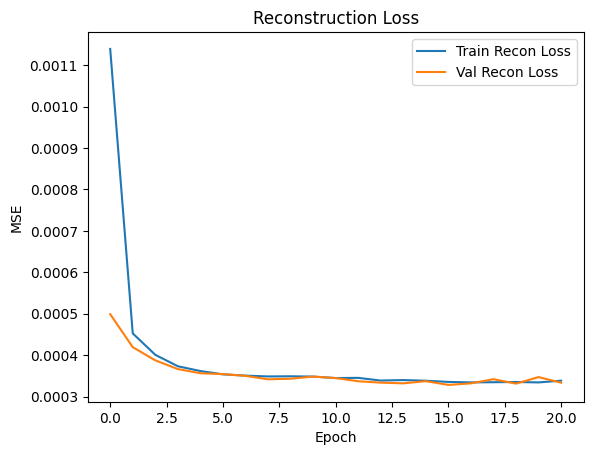

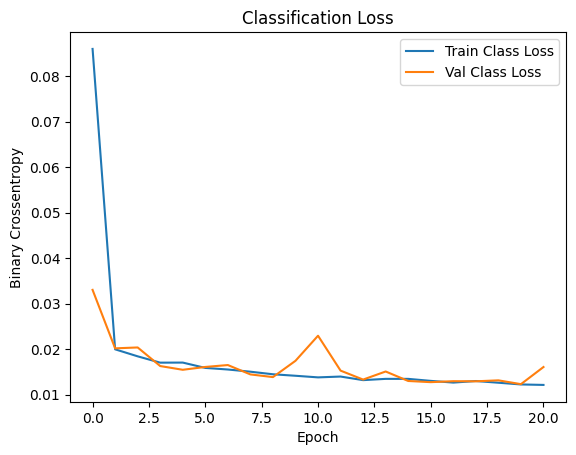

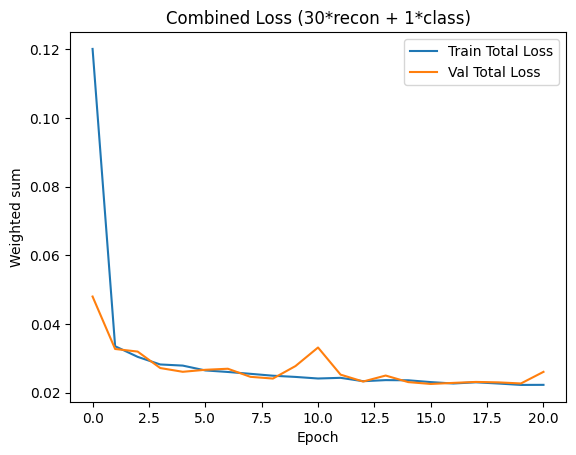

I0000 00:00:1776721731.932831    9559 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17300283__.5
I0000 00:00:1776721732.086301  304577 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads



3173/3251 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step

I0000 00:00:1776721733.538517    9553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17310272__.5
I0000 00:00:1776721733.716527  304709 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads



3251/3251 ━━━━━━━━━━━━━━━━━━━━ 2s 483us/step


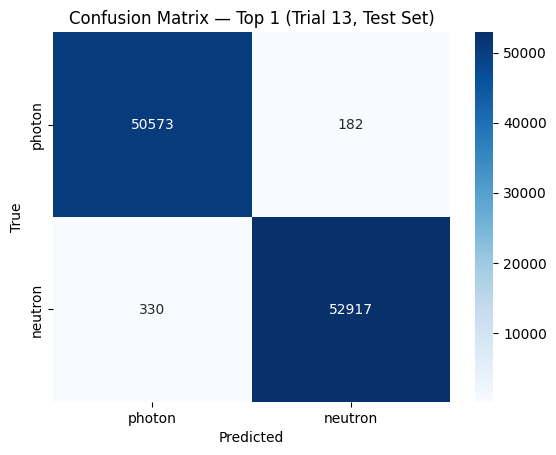

: 

In [ ]:
# Load the hyperparameter results CSV, pick top 1, retrain, plot train+val curves.
import os
import pandas as pd

os.makedirs("figures", exist_ok=True)

df = pd.read_csv("SinglesApril14_hyperparam_results.csv")
df_sorted = df.sort_values("best_val_acc", ascending=False).reset_index(drop=True)
top1 = df_sorted.head(1).copy()

print("Top 1 configuration by best_val_acc:")
print(top1[["trial", "conv_filters", "dense_units", "lr", "num_layers", "best_val_acc"]].to_string(index=False))

row = top1.iloc[0]
params = {
    "latent_dim":   int(row["latent_dim"]),
    "conv_filters": eval(row["conv_filters"]),
    "dense_units":  int(row["dense_units"]),
    "lr":           float(row["lr"]),
    "num_layers":   int(row["num_layers"]),
}

tf.keras.backend.clear_session()
gc.collect()
print(f"\n=== Training top-1 config (trial {int(row['trial'])}): {params} ===")
m = build_model(**params)
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, mode="min"
)

m.compile(
    optimizer='adam',
    loss={
        'reconstruction': 'mse',
        'classification': 'binary_crossentropy'},
    loss_weights={
        'reconstruction': 30.0,
        'classification': 1.0},
    metrics={
        'classification': ['accuracy']})

history = m.fit(
    X_train,
    {"reconstruction": X_train, "classification": Y_train},
    validation_data=(X_val, {"reconstruction": X_val, "classification": Y_val}),
    epochs=100,
    batch_size=256,
    callbacks=[es],
    verbose=2,
)



# Reconstruction loss
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig("figures/singles_top1_reconstruction_loss.png", dpi=120, bbox_inches="tight")
plt.show()

# Classification loss
plt.figure()
plt.plot(history.history['classification_loss'], label='Train Class Loss')
plt.plot(history.history['val_classification_loss'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.savefig("figures/singles_top1_classification_loss.png", dpi=120, bbox_inches="tight")
plt.show()

# Combined loss
plt.figure()
plt.plot(history.history['loss'], label='Train Total Loss')
plt.plot(history.history['val_loss'], label='Val Total Loss')
plt.title('Combined Loss (30*recon + 1*class)')
plt.xlabel('Epoch')
plt.ylabel('Weighted sum')
plt.legend()
plt.savefig("figures/singles_top1_combined_loss.png", dpi=120, bbox_inches="tight")
plt.show()

# Confusion matrix
y_pred = m.predict(X_test)[1]
y_pred_bin = (y_pred > 0.5).astype(int)

cm = confusion_matrix(Y_test, y_pred_bin)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["photon", "neutron"], yticklabels=["photon", "neutron"])
plt.title(f'Confusion Matrix — Top 1 (Trial {int(row["trial"])}, Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig("figures/singles_top1_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
